Setup terminé ✓

=== Tour 1 — blanc — dés : [4, 5] ===
Séquence jouée : [(2, 6, 4), (1, 6, 5)]


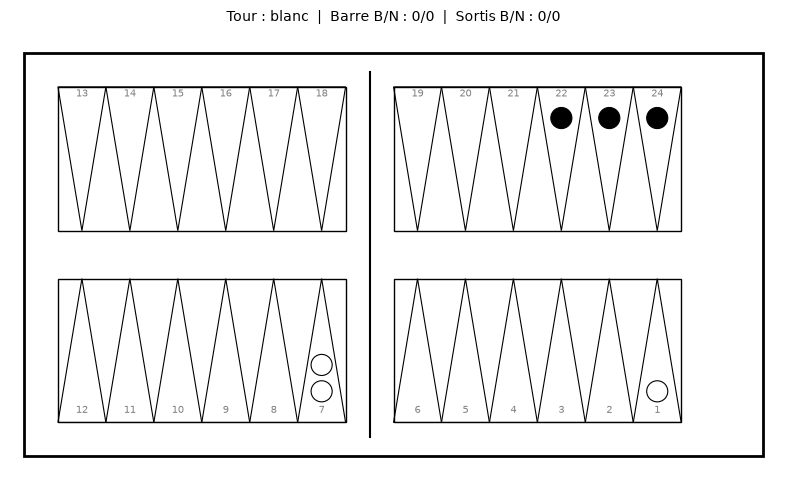


=== Tour 2 — noir — dés : [5, 5, 5, 5] ===
Séquence jouée : [(22, 17, 5), (17, 12, 5), (21, 16, 5), (12, 7, 5)]


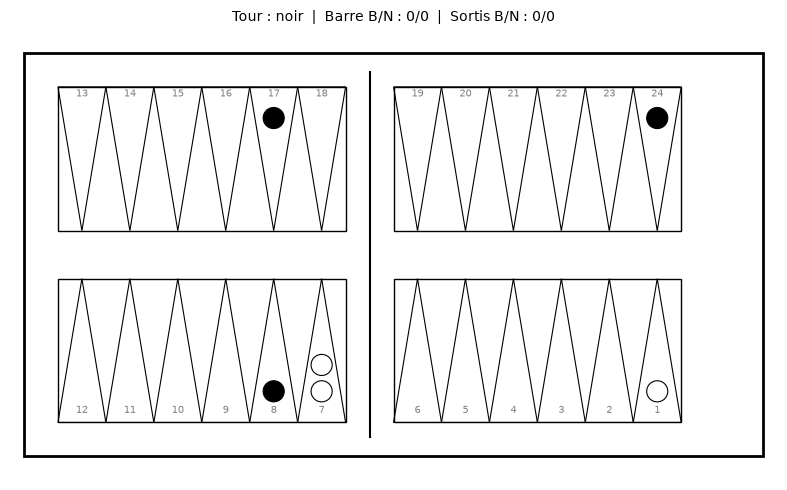


=== Tour 3 — blanc — dés : [3, 6] ===
Séquence jouée : [(6, 9, 3), (9, 15, 6)]


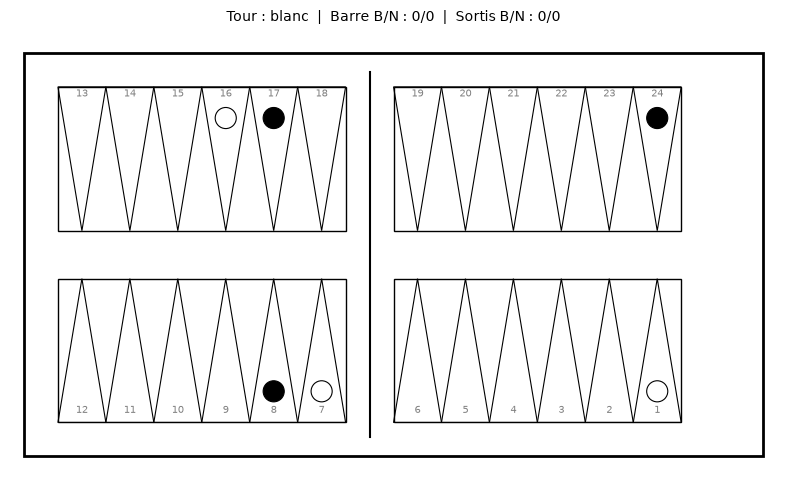


=== Tour 4 — noir — dés : [2, 4] ===
Séquence jouée : [(16, 14, 2), (23, 19, 4)]


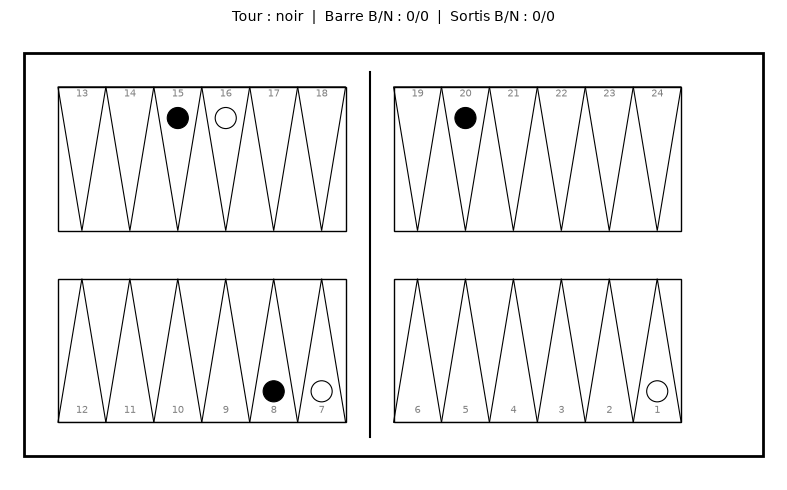


=== Tour 5 — blanc — dés : [2, 4] ===
Séquence jouée : [(6, 8, 2), (8, 12, 4)]


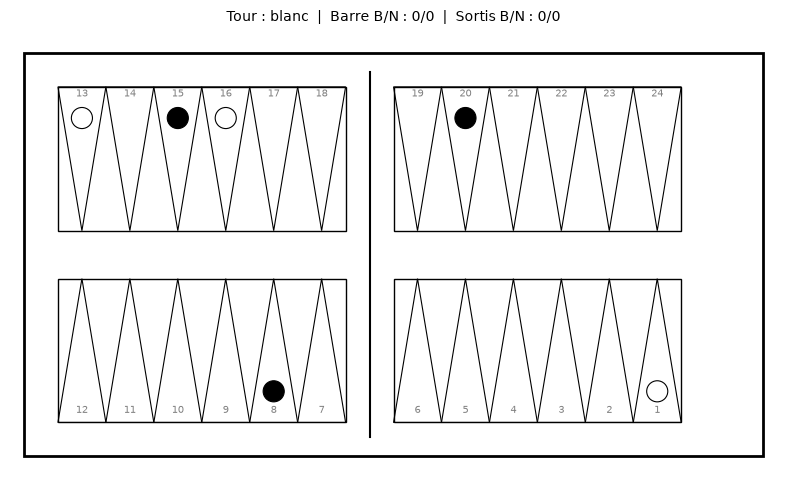


=== Tour 6 — noir — dés : [1, 4] ===
Séquence jouée : [(14, 13, 1), (19, 15, 4)]


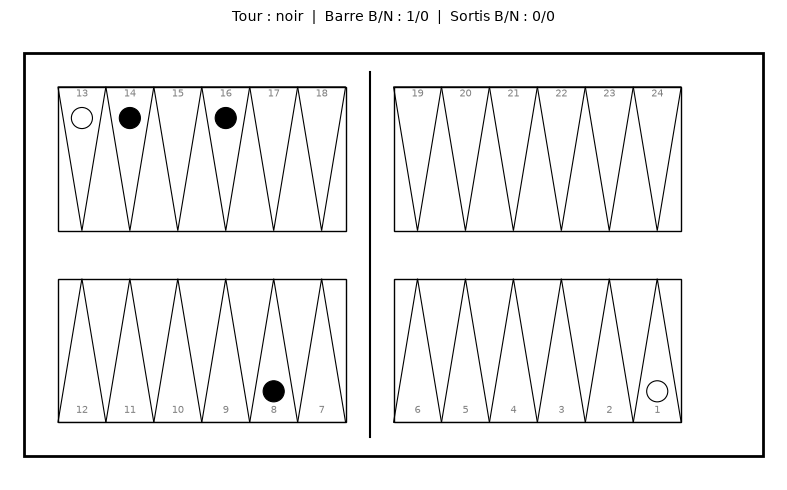


=== Tour 7 — blanc — dés : [5, 4] ===
Séquence jouée : [(-1, 4, 5), (0, 4, 4)]


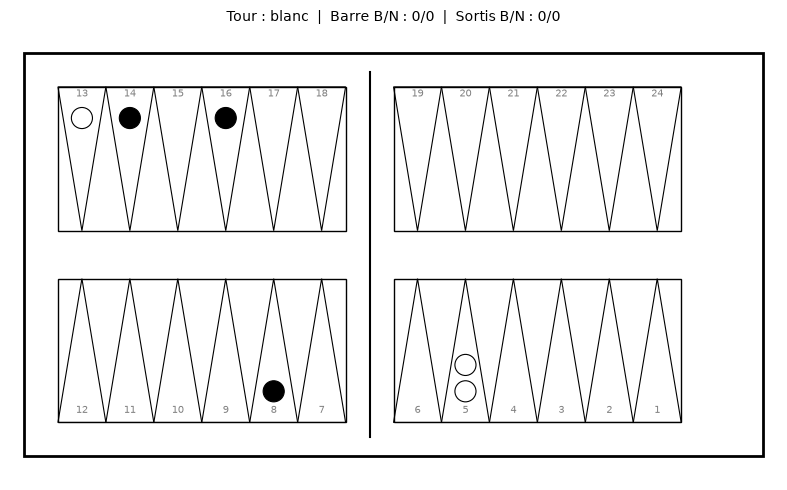


=== Tour 8 — noir — dés : [1, 3] ===
Séquence jouée : [(7, 6, 1), (15, 12, 3)]


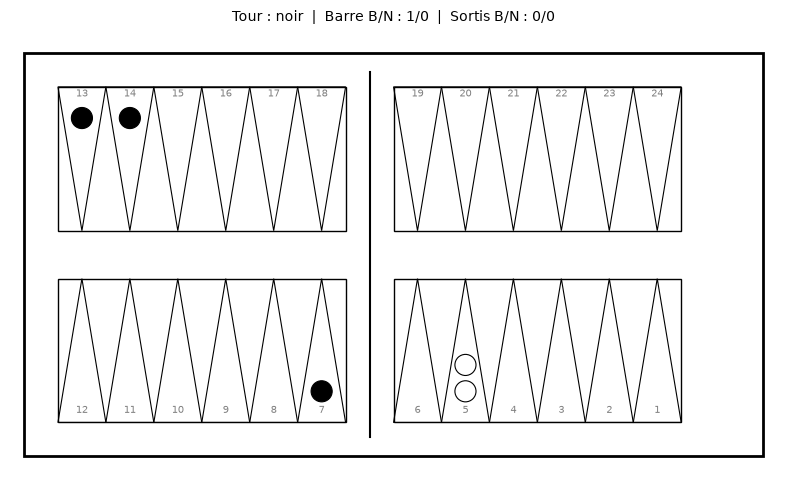


=== Tour 9 — blanc — dés : [2, 4] ===
Séquence jouée : [(-1, 1, 2), (4, 8, 4)]


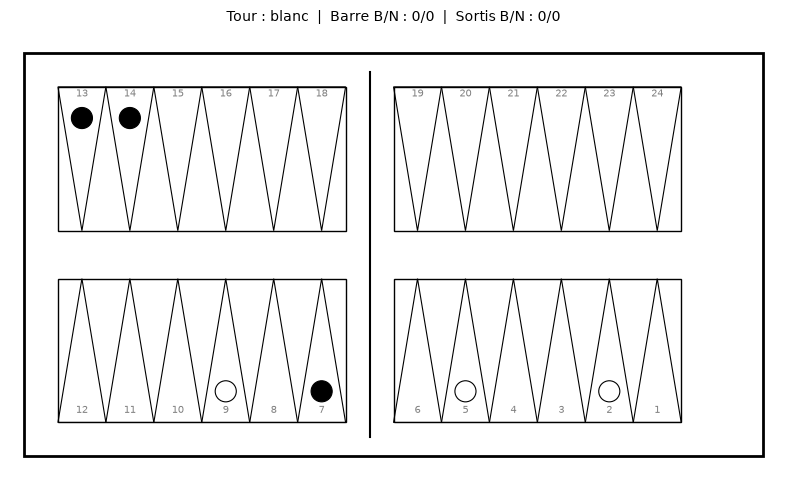


=== Tour 10 — noir — dés : [6, 6, 6, 6] ===
Séquence jouée : [(13, 7, 6), (6, 0, 6), (12, 6, 6), (7, 1, 6)]


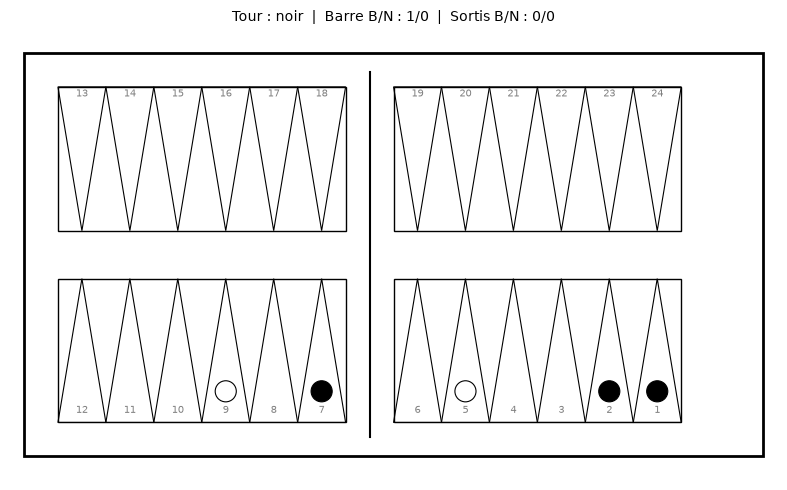

Partie 1 : 27 tours — gagnant : blanc
Partie 2 : 19 tours — gagnant : blanc
Partie 3 : 25 tours — gagnant : blanc
Partie 4 : 16 tours — gagnant : noir
Partie 5 : 18 tours — gagnant : noir
Import réussi ✓ — board initial : [ 1.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0. -1. -1. -1.]


In [1]:
import sys
sys.path.append('../src')
from backgammon_env import *

import numpy as np
import matplotlib.pyplot as plt

env = BackgammonEnv()
print("Import réussi ✓ — board initial :", env.board)

In [2]:
def encoder_case(nb_pions):
    unites = [0, 0, 0]
    for i in range(min(nb_pions, 3)):
        unites[i] = 1
    return unites


def encoder_etat(env):
    inputs = []
    for case in range(24):
        valeur = env.board[case]
        nb_blanc = int(valeur) if valeur > 0 else 0
        nb_noir = int(-valeur) if valeur < 0 else 0
        inputs.extend(encoder_case(nb_blanc))
        inputs.extend(encoder_case(nb_noir))
    
    inputs.append(env.bar_blanc / env.n_pions)
    inputs.append(env.bar_noir / env.n_pions)
    inputs.append(env.sortis_blanc / env.n_pions)
    inputs.append(env.sortis_noir / env.n_pions)
    inputs.append(1.0 if env.joueur_actuel == "blanc" else 0.0)
    
    return np.array(inputs)


# Test immediat
env = BackgammonEnv()
v = encoder_etat(env)
assert len(v) == 149, f"Taille incorrecte : {len(v)}"
print("Encodage OK — taille :", len(v))

Encodage OK — taille : 149


In [3]:
class ReseauTDGammon:
    """
    MLP 149 -> 80 -> 1, TD(lambda) avec traces, forward vectorise par batch.
    Configuration alignee sur Tesauro : lam=0.7, alpha 0.1 -> 0.01.
    """
    
    def __init__(self, n_inputs=149, n_caches=80, alpha=0.1, lam=0.7):
        self.alpha = alpha
        self.lam = lam
        self.W1 = np.random.randn(n_inputs, n_caches) * 0.1
        self.b1 = np.zeros(n_caches)
        self.W2 = np.random.randn(n_caches, 1) * 0.1
        self.b2 = np.zeros(1)
        self.reset_traces()
    
    def reset_traces(self):
        self.tW1 = np.zeros_like(self.W1)
        self.tb1 = np.zeros_like(self.b1)
        self.tW2 = np.zeros_like(self.W2)
        self.tb2 = np.zeros_like(self.b2)
    
    def sigmoid(self, x):
        return 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))
    
    def forward(self, x):
        """Forward sur UN etat (vecteur 149) — pour l'apprentissage."""
        self.x = x
        self.z1 = x @ self.W1 + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2[0]
    
    def forward_batch(self, X):
        """
        Forward sur N etats d'un coup (matrice N x 149).
        Retourne un vecteur de N valeurs. C'est LA optimisation cle :
        une seule multiplication matricielle au lieu de N passes separees.
        """
        A1 = self.sigmoid(X @ self.W1 + self.b1)
        A2 = self.sigmoid(A1 @ self.W2 + self.b2)
        return A2.flatten()
    
    def update_td_lambda(self, td_error):
        grad_sortie = self.a2 * (1 - self.a2)
        gW2 = np.outer(self.a1, grad_sortie)
        gb2 = grad_sortie
        delta1 = (grad_sortie @ self.W2.T) * self.a1 * (1 - self.a1)
        gW1 = np.outer(self.x, delta1)
        gb1 = delta1
        
        self.tW1 = self.lam * self.tW1 + gW1
        self.tb1 = self.lam * self.tb1 + gb1.flatten()
        self.tW2 = self.lam * self.tW2 + gW2
        self.tb2 = self.lam * self.tb2 + gb2.flatten()
        
        self.W1 += self.alpha * td_error * self.tW1
        self.b1 += self.alpha * td_error * self.tb1
        self.W2 += self.alpha * td_error * self.tW2
        self.b2 += self.alpha * td_error * self.tb2
    
    def copier_poids(self):
        return (self.W1.copy(), self.b1.copy(), self.W2.copy(), self.b2.copy())
    
    def restaurer_poids(self, poids):
        self.W1, self.b1, self.W2, self.b2 = [p.copy() for p in poids]

In [4]:
def simuler_sequence(env, seq):
    """
    Applique une sequence de coups sur une COPIE legere de l'etat,
    sans recreer un environnement complet (optimisation de vitesse).
    Retourne un objet etat minimal, compatible avec l'encodage.
    """
    class EtatSimule:
        pass
    
    sim = EtatSimule()
    sim.board = env.board.copy()
    sim.bar_blanc = env.bar_blanc
    sim.bar_noir = env.bar_noir
    sim.sortis_blanc = env.sortis_blanc
    sim.sortis_noir = env.sortis_noir
    sim.joueur_actuel = env.joueur_actuel
    sim.n_pions = env.n_pions
    
    s = 1 if env.joueur_actuel == "blanc" else -1
    
    for (depart, arrivee, de) in seq:
        if depart == -1:
            if s == 1:
                sim.bar_blanc -= 1
            else:
                sim.bar_noir -= 1
        else:
            sim.board[depart] -= s
        
        if arrivee == -1:
            if s == 1:
                sim.sortis_blanc += 1
            else:
                sim.sortis_noir += 1
            continue
        
        if sim.board[arrivee] * s == -1:
            sim.board[arrivee] = 0
            if s == 1:
                sim.bar_noir += 1
            else:
                sim.bar_blanc += 1
        
        sim.board[arrivee] += s
    
    return sim


def encoder_etat_simule(sim):
    """
    Version de encoder_etat qui fonctionne sur l'objet EtatSimule
    (meme logique que encoder_etat, applique a l'etat simule).
    """
    inputs = []
    
    for case in range(24):
        valeur = sim.board[case]
        nb_blanc = int(valeur) if valeur > 0 else 0
        nb_noir = int(-valeur) if valeur < 0 else 0
        
        inputs.extend(encoder_case(nb_blanc))
        inputs.extend(encoder_case(nb_noir))
    
    inputs.append(sim.bar_blanc / sim.n_pions)
    inputs.append(sim.bar_noir / sim.n_pions)
    inputs.append(sim.sortis_blanc / sim.n_pions)
    inputs.append(sim.sortis_noir / sim.n_pions)
    inputs.append(1.0 if sim.joueur_actuel == "blanc" else 0.0)
    
    return inputs


def choisir_meilleure_sequence(env, sequences, reseau):
    """
    Choisit la meilleure sequence de coups parmi celles disponibles.
    VERSION VECTORISEE : encode tous les etats candidats en une seule
    matrice, puis un seul forward_batch au lieu de N forwards separes.
    Blanc maximise V(s'), Noir minimise V(s').
    """
    if len(sequences) == 1:
        return sequences[0]
    
    X = np.array([encoder_etat_simule(simuler_sequence(env, seq))
                  for seq in sequences])
    valeurs = reseau.forward_batch(X)
    
    if env.joueur_actuel == "blanc":
        return sequences[np.argmax(valeurs)]
    return sequences[np.argmin(valeurs)]

In [5]:
def evaluer_contre_random(reseau, n_parties=100):
    victoires = 0
    for _ in range(n_parties):
        env = BackgammonEnv()
        env.reset()
        for tour in range(500):
            des = lancer_des()
            sequences = env.coups_disponibles(des)
            if sequences:
                if env.joueur_actuel == "blanc":
                    seq = choisir_meilleure_sequence(env, sequences, reseau)
                else:
                    seq = sequences[np.random.randint(len(sequences))]
                for (depart, arrivee, de) in seq:
                    env.jouer_coup(depart, arrivee)
            gagnant = env.partie_terminee()
            if gagnant:
                if gagnant == "blanc":
                    victoires += 1
                break
            env.changer_joueur()
    return victoires / n_parties

In [6]:
def entrainer_final(n_parties=100000, alpha_debut=0.1, alpha_fin=0.01,
                    lam=0.7, eval_tous_les=5000):
    """
    Configuration alignee sur la litterature :
    - PAS d'epsilon (les des fournissent l'exploration naturelle)
    - lam=0.7, alpha 0.1 -> 0.01 (valeurs de Tesauro)
    - 100 000 parties minimum
    """
    reseau = ReseauTDGammon(n_inputs=149, n_caches=80,
                            alpha=alpha_debut, lam=lam)
    historique_winrate = []
    meilleur_winrate = 0.0
    meilleurs_poids = reseau.copier_poids()
    
    for partie in range(n_parties):
        reseau.alpha = alpha_debut + (alpha_fin - alpha_debut) * (partie / n_parties)
        
        env = BackgammonEnv()
        env.reset()
        reseau.reset_traces()
        
        etat_precedent = encoder_etat(env)
        V_precedent = reseau.forward(etat_precedent)
        
        for tour in range(500):
            des = lancer_des()
            sequences = env.coups_disponibles(des)
            
            if sequences:
                seq = choisir_meilleure_sequence(env, sequences, reseau)
                for (depart, arrivee, de) in seq:
                    env.jouer_coup(depart, arrivee)
            
            gagnant = env.partie_terminee()
            
            if gagnant:
                reward = 1.0 if gagnant == "blanc" else 0.0
                td_error = reward - V_precedent
                reseau.forward(etat_precedent)
                reseau.update_td_lambda(td_error)
                break
            
            env.changer_joueur()
            etat_nouveau = encoder_etat(env)
            V_nouveau = reseau.forward(etat_nouveau)
            td_error = V_nouveau - V_precedent
            reseau.forward(etat_precedent)
            reseau.update_td_lambda(td_error)
            etat_precedent = etat_nouveau
            V_precedent = V_nouveau
        
        if (partie + 1) % eval_tous_les == 0:
            winrate = evaluer_contre_random(reseau, n_parties=200)
            historique_winrate.append(winrate)
            marqueur = ""
            if winrate > meilleur_winrate:
                meilleur_winrate = winrate
                meilleurs_poids = reseau.copier_poids()
                marqueur = " *** record ***"
            print(f"Partie {partie+1}/{n_parties} — alpha {reseau.alpha:.4f} — "
                  f"winrate {winrate:.1%}{marqueur}")
    
    reseau.restaurer_poids(meilleurs_poids)
    print(f"\nMeilleur réseau — winrate : {meilleur_winrate:.1%}")
    return reseau, historique_winrate, meilleur_winrate

In [7]:
# ETAPE 1 : test de vitesse sur 500 parties avant de s'engager sur 100 000
import time

t0 = time.time()
_, _, _ = entrainer_final(n_parties=500, eval_tous_les=500)
duree_500 = time.time() - t0

estimation_100k = duree_500 * 200 / 3600
print(f"\n500 parties en {duree_500:.0f}s")
print(f"Estimation pour 100 000 parties : {estimation_100k:.1f} heures")

print("Fonctions chargées ✓")
print(choisir_meilleure_sequence)

Partie 500/500 — alpha 0.0102 — winrate 55.0% *** record ***

Meilleur réseau — winrate : 55.0%

500 parties en 26s
Estimation pour 100 000 parties : 1.4 heures
Fonctions chargées ✓
<function choisir_meilleure_sequence at 0x000002645E5CECF0>


Partie 4000/40000 — alpha 0.0910 — winrate 84.5% *** record ***
Partie 8000/40000 — alpha 0.0820 — winrate 87.0% *** record ***
Partie 12000/40000 — alpha 0.0730 — winrate 82.5%
Partie 16000/40000 — alpha 0.0640 — winrate 85.5%
Partie 20000/40000 — alpha 0.0550 — winrate 82.5%
Partie 24000/40000 — alpha 0.0460 — winrate 82.5%
Partie 28000/40000 — alpha 0.0370 — winrate 85.5%
Partie 32000/40000 — alpha 0.0280 — winrate 84.5%
Partie 36000/40000 — alpha 0.0190 — winrate 87.5% *** record ***
Partie 40000/40000 — alpha 0.0100 — winrate 87.0%

Meilleur réseau — winrate : 87.5%
Fichier sauvegardé — taille : 96866 octets
Sauvegarde confirmée ✓

Durée : 56.8 minutes
Winrate final (500 parties) : 85.8%


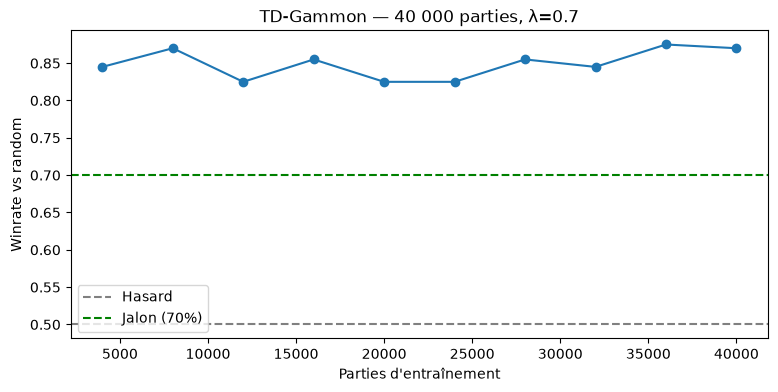

In [8]:
import pickle
import time
import os

t0 = time.time()
reseau, winrates, record = entrainer_final(n_parties=40000, eval_tous_les=4000)
duree = time.time() - t0

# SAUVEGARDE IMMEDIATE avec verification — avant tout autre affichage
chemin = '../outputs/reseau_final.pkl'
with open(chemin, 'wb') as f:
    pickle.dump(reseau.copier_poids(), f)

taille = os.path.getsize(chemin)
print(f"Fichier sauvegardé — taille : {taille} octets")
assert taille > 0, "ERREUR : le fichier est vide, la sauvegarde a échoué"
print("Sauvegarde confirmée ✓\n")

print(f"Durée : {duree/60:.1f} minutes")
winrate_final = evaluer_contre_random(reseau, n_parties=500)
print(f"Winrate final (500 parties) : {winrate_final:.1%}")

x_axis = [4000 * (i + 1) for i in range(len(winrates))]
plt.figure(figsize=(9, 4))
plt.plot(x_axis, winrates, marker='o')
plt.axhline(y=0.5, color='gray', linestyle='--', label='Hasard')
plt.axhline(y=0.7, color='green', linestyle='--', label='Jalon (70%)')
plt.xlabel("Parties d'entraînement")
plt.ylabel("Winrate vs random")
plt.title("TD-Gammon — 40 000 parties, λ=0.7")
plt.legend()
plt.show()